In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import factorial
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch


pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [40]:
# Phisical Constants
h = 6.62607015e-34  # Planck's constant (J·s)
c = 2.99792458e8    # Light speed (m/s)
kB = 1.380649e-23   # Boltzmann's constant (J/K)

In [55]:
def planck_lambda(lam, T):
    """
       Computes the energy density according to the Planck's distribution.
    """
    
    x = (h * c) / (lam * kB * T)
    
    num = 8 * np.pi * h * c
    den = (lam**5) * (np.exp(x) - 1)
    
    return num / den



In [10]:
def rayleigh_jeans_lambda(lam, T):
    """
    Computes the energy density according to the Rayleigh-Jeans distribution.
    """
    return (8 * np.pi * kB * T) / (lam**4)

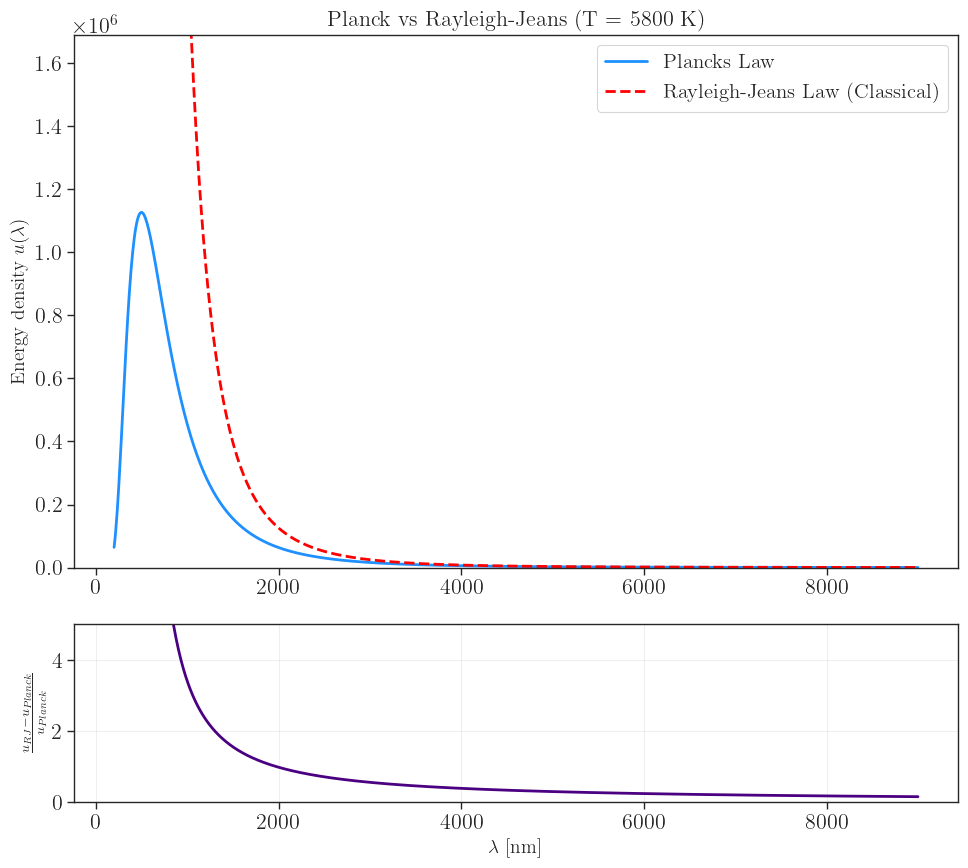

In [54]:



T = 5800  # Temeprature of the sun


lam = np.linspace(200e-9, 9000e-9, 1000) 


u_planck = planck_lambda(lam, T)
u_rj = rayleigh_jeans_lambda(lam, T)

# Relative difference
# (u_RJ - u_Planck) / u_Planck
rel_diff = (u_rj - u_planck) / u_planck

#Plot
fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw = {'height_ratios':[3, 1]},figsize=(10,9))


ax1.plot(lam * 1e9, u_planck, label='Plancks Law', color='dodgerblue', linewidth=2)
ax1.plot(lam * 1e9, u_rj, label='Rayleigh-Jeans Law (Classical)', color='red', linestyle='--', linewidth=2)


ymax = np.max(u_planck) * 1.5
ax1.set_ylim(0, ymax)

ax1.set_title(f"Planck vs Rayleigh-Jeans (T = {T} K)", fontsize=16)
ax1.set_ylabel(r"Energy density $u(\lambda)$", fontsize=14)
ax1.legend(fontsize=15)



ax2.plot(lam * 1e9, rel_diff, color='indigo', linewidth=2)

ax2.set_xlabel(r"$\lambda$ [nm]", fontsize=14)
ax2.set_ylabel(r"$\frac{u_{RJ} - u_{Planck}}{u_{Planck}}$", fontsize=14)
ax2.set_ylim(0, 5)
ax2.grid(True, alpha=0.3)




plt.tight_layout()
plt.savefig('Pl_vs_RJ.png')
plt.show()

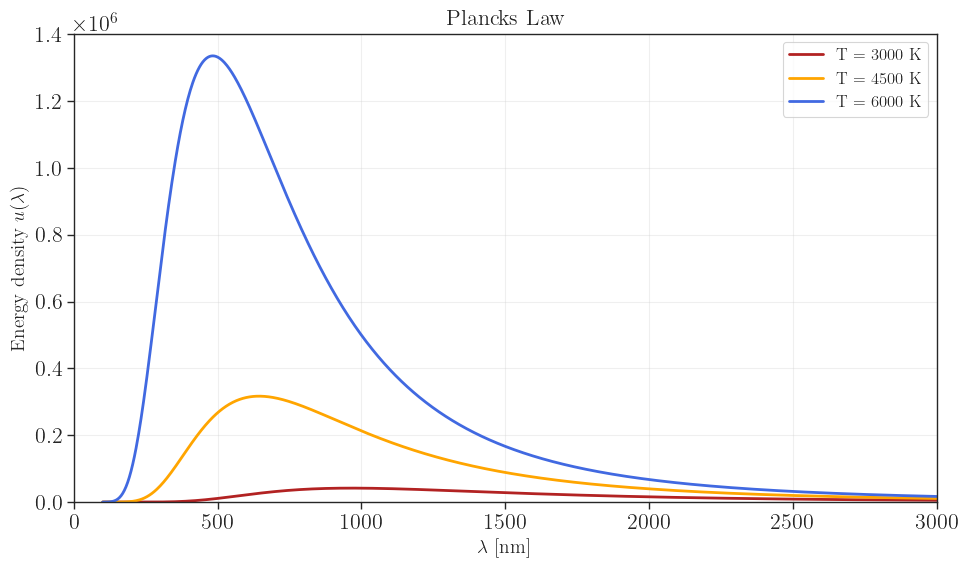

In [45]:

temp = [3000, 4500, 6000]
colors = ['firebrick', 'orange', 'royalblue']


lam = np.linspace(100e-9, 3000e-9, 1000) 


fig, ax = plt.subplots(figsize=(10, 6))

for T, cl in zip(temp, colors):
    u = planck_lambda(lam, T)
    ax.plot(lam * 1e9, u, label=f'T = {T} K', color=cl, linewidth=2)

ax.set_title("Plancks Law", fontsize=16)
ax.set_xlabel(r"$\lambda$ [nm]", fontsize=14)
ax.set_ylabel(r"Energy density $u(\lambda)$", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
ax.set_xlim(0, 3000)

plt.tight_layout()
plt.savefig('Pl_dist.png')
plt.show()